# Intent classifier: classical ML vs. LLM

Classify customer messages into 5 intents — `pricing`, `complaint`, `cancellation`, `tech_support`, `other` — and compare:

| | Method |
|---|---|
| A | TF-IDF (word + char n-gram) + logistic regression |
| B | Embedding `text-embedding-3-small` + logistic regression |
| C | Embedding + XGBoost |
| D | LLM zero-shot (`gpt-4o-mini`) |

Then try a **hybrid strategy**: the cheap model answers when it is confident; everything else goes to the LLM.

> This notebook re-runs **without an API key**: embeddings, LLM predictions and API latencies are cached in `data/cache/`. Models A/B/C are retrained inside the notebook.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

from intent_router import experiments as ex
from intent_router.config import CACHE, DATA, EMBED_MODEL, LABELS, LLM_MODEL, cost_usd
from intent_router.embed import embed_texts
from intent_router.llm import load_cache

pd.set_option("display.max_colwidth", 120)
PER = 100_000

## 1. Data

- **300 hand-labeled messages** (`data/seed_raw.tsv`) following the [labeling guide](../data/LABELING_GUIDE.md) — with diacritics, without diacritics, teencode, Vietglish, and hard cases.
- **1,700 messages generated with `gpt-4o-mini`** (varied writing styles, personas, ~20% hard cases), then **labeled independently with `gpt-4o`** using the same guide.
- `cancellation` is the rare class (~10%) → use `class_weight="balanced"` / sample weights and a stratified split.

In [2]:
df = ex.load_data()
report = json.loads((DATA / "dataset_report.json").read_text())
pd.crosstab(df.label, df.split, margins=True).loc[LABELS + ["All"], ["train", "val", "test", "All"]]

split,train,val,test,All
label,,,,
pricing,303,65,65,433
complaint,288,61,62,411
cancellation,146,32,31,209
tech_support,386,82,83,551
other,277,60,59,396
All,1400,300,300,2000


### LLM label quality checks

1. **LLM annotator vs. human labels** on the 300 seed messages.
2. **Spot check**: 100 randomly chosen LLM-labeled messages, re-reviewed by a human (`data/audit_sample.csv`). Labels the human corrected are written back into the dataset.

In [3]:
sa, au = report["seed_agreement"], report["audit"]
print(f"Annotator vs human (300 seed): accuracy = {sa['accuracy']:.1%}, Cohen's kappa = {sa['cohen_kappa']:.3f}")
print(f"Spot check (100 LLM-labeled):  agreement = {au['agreement']:.0%}")
print(f"Annotator label matches generation intent: {report['generation_intent_agreement']:.1%}")
pd.DataFrame(sa["disagreements"] + [{"text": d["text"], "human": d["human_label"], "llm": d["llm_label"]} for d in au["disagreements"]])

Annotator vs human (300 seed): accuracy = 99.0%, Cohen's kappa = 0.987
Spot check (100 LLM-labeled):  agreement = 95%
Annotator label matches generation intent: 89.5%


,text,human,llm
0,"Báo cáo bị lệch số so với dữ liệu thực tế, kiểm tra giúp mình",tech_support,complaint
1,Không thấy dữ liệu tuần trước trên dashboard,tech_support,complaint
2,tìm kiếm không ra kết quả dù task có tồn tại,tech_support,complaint
3,"Nhân viên văn phòng báo cắt dịch vụ mà không thấy thông báo gì, rất khó chịu.",complaint,cancellation
4,Cảm giác như một số tính năng còn phức tạp hơn mình nghĩ. Có must-have nào không?,tech_support,other
5,Nếu mình gia hạn mà ko sử dụng thì có được hoàn lại ko?,pricing,cancellation
6,Các bạn có bí kíp nào dùng tốt hơn không?,tech_support,other
7,Làm ơn cho mình biết là có diễn đàn hỗ trợ trực tuyến không? Mình thích tham gia với các anh chị em khác. Thank you!,other,tech_support


## 2. Train A / B / C, predict D

Train on `train`, report on `test`. 5-fold cross-validation on `train+val`.

In [4]:
tr, te = (df[df.split == s].reset_index(drop=True) for s in ("train", "test"))
trva = df[df.split != "test"].reset_index(drop=True)
E = dict(zip(df.text, embed_texts(df.text.tolist())))   # from cache
emb = lambda part: np.stack([E[t] for t in part.text])
inputs = {
    "A": {"tr": tr.text.tolist(), "te": te.text.tolist(), "trva": trva.text.tolist()},
    "B": {"tr": emb(tr), "te": emb(te), "trva": emb(trva)},
}
inputs["C"] = inputs["B"]

models, probas, preds, cv, oof = {}, {}, {}, {}, {}
for k in "ABC":
    cv[k], oof[k] = ex.cross_validate(k, inputs[k]["trva"], trva.label.values)
    models[k] = ex.FACTORIES[k]().fit(inputs[k]["tr"], tr.label.values)
    probas[k] = ex.proba_in_label_order(models[k], inputs[k]["te"])
    preds[k] = np.array(LABELS)[probas[k].argmax(1)]
    print(f"{ex.NAMES[k]:<36} CV macro-F1 = {np.mean(cv[k]):.3f} ± {np.std(cv[k]):.3f}")

zs = load_cache(CACHE / f"zeroshot_{LLM_MODEL}.jsonl")
preds["D"] = np.array([zs[t]["label"] for t in te.text])

A. TF-IDF + logistic regression      CV macro-F1 = 0.886 ± 0.011


B. Embedding + logistic regression   CV macro-F1 = 0.902 ± 0.016


C. Embedding + XGBoost               CV macro-F1 = 0.879 ± 0.020


### Latency & cost

- **A**: time to predict one message at a time on the local machine.
- **B, C**: 1 embedding API call per message (measured for real, cached in `embed_latency_*.jsonl`) + classifier time.
- **D**: 1 `gpt-4o-mini` call per message (measured for real).
- Cost per 100k messages = actual average tokens × 100k × list price (`config.PRICES`).

In [5]:
emb_lat = load_cache(CACHE / f"embed_latency_{EMBED_MODEL}.jsonl")
emb_ms = np.array([emb_lat[t]["latency_ms"] for t in te.text])
llm_ms = np.array([zs[t]["latency_ms"] for t in te.text])
emb_cost = cost_usd(EMBED_MODEL, np.mean([emb_lat[t]["input_tokens"] for t in te.text]) * PER)
llm_cost = cost_usd(LLM_MODEL, np.mean([zs[t]["input_tokens"] for t in te.text]) * PER,
                    np.mean([zs[t]["output_tokens"] for t in te.text]) * PER)

ms = {"A": ex.per_message_ms(lambda x: models["A"].predict_proba([x]), inputs["A"]["te"], repeats=3)}
for k in "BC":
    ms[k] = ex.per_message_ms(lambda x, m=models[k]: m.predict_proba(x[None]), inputs[k]["te"], repeats=3) + emb_ms
ms["D"] = llm_ms
cost = {"A": 0.0, "B": emb_cost, "C": emb_cost, "D": llm_cost}

rows = []
for k in "ABCD":
    lo, hi = ex.bootstrap_ci(te.label, preds[k])
    rows.append({
        "Method": ex.NAMES[k],
        "Macro-F1 test": round(ex.macro_f1(te.label, preds[k]), 3),
        "95% CI (bootstrap)": f"{lo:.2f}–{hi:.2f}",
        "Macro-F1 CV": f"{np.mean(cv[k]):.3f} ± {np.std(cv[k]):.3f}" if k in cv else "—",
        "p50 (ms)": round(np.percentile(ms[k], 50), 1),
        "p95 (ms)": round(np.percentile(ms[k], 95), 1),
        "$/100k msgs": round(cost[k], 2),
    })
comparison = pd.DataFrame(rows).set_index("Method")
comparison

,Macro-F1 test,95% CI (bootstrap),Macro-F1 CV,p50 (ms),p95 (ms),$/100k msgs
Method,,,,,,
A. TF-IDF + logistic regression,0.906,0.87–0.94,0.886 ± 0.011,0.6,0.8,0.00
B. Embedding + logistic regression,0.882,0.84–0.92,0.902 ± 0.016,235.6,317.8,0.06
C. Embedding + XGBoost,0.896,0.86–0.93,0.879 ± 0.020,235.8,318.1,0.06
D. LLM zero-shot,0.943,0.92–0.97,—,736.9,911.1,3.23


How to read the table:
- The 95% confidence intervals of A/B/C **overlap** on the 300 test messages → don't conclude A beats B from a single split. 5-fold CV (1,700 messages) is more stable: B is slightly ahead among the cheap models.
- D is clearly better (~+4 macro-F1 points), but **~1,000× slower** than A and **~50× more expensive** than B.

## 3. Confusion matrix

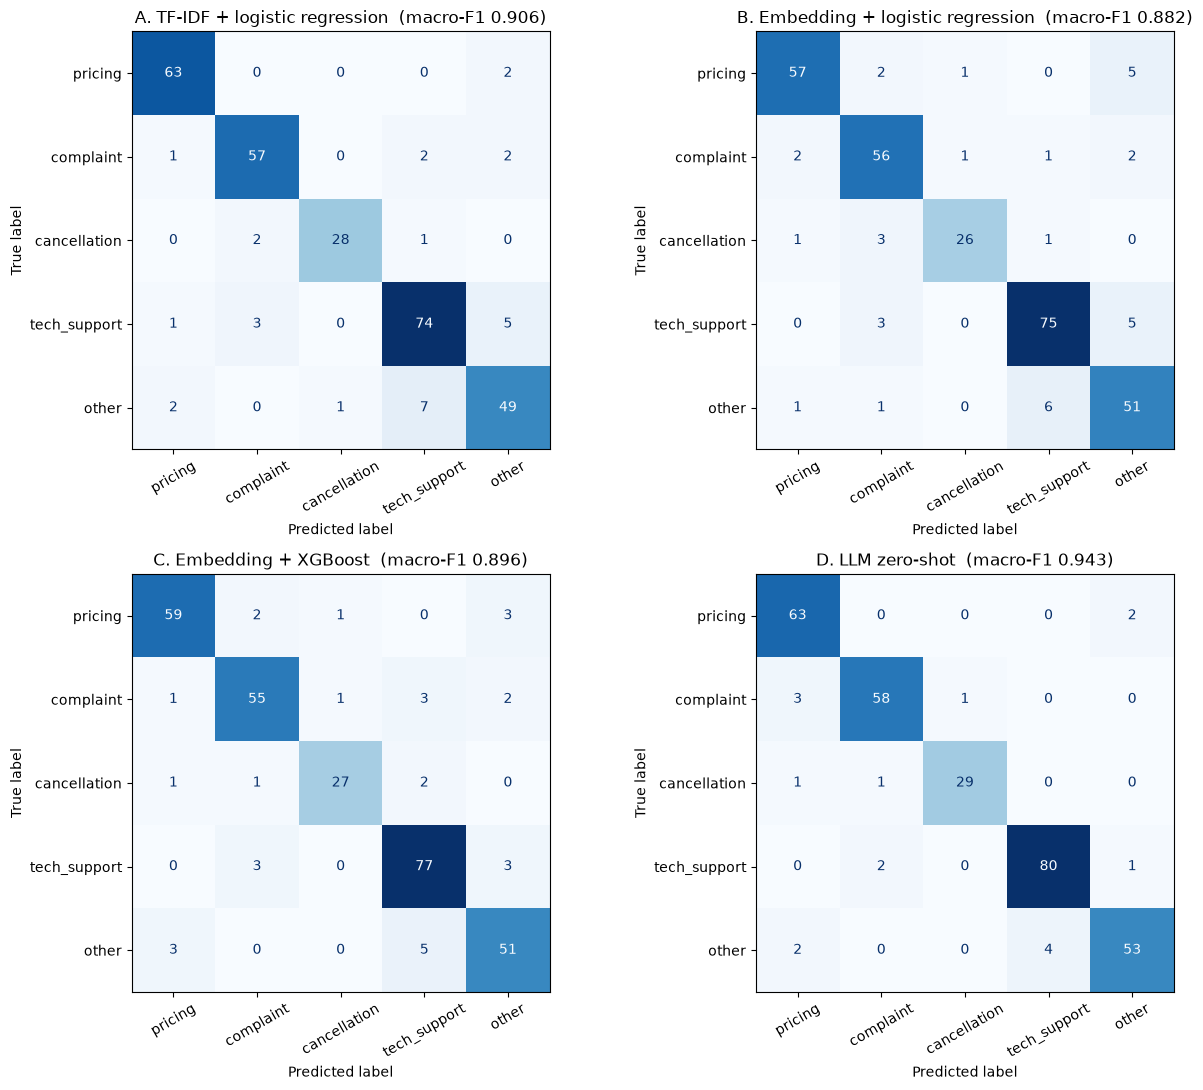

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, k in zip(axes.flat, "ABCD"):
    cm = confusion_matrix(te.label, preds[k], labels=LABELS)
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=30)
    ax.set_title(f"{ex.NAMES[k]}  (macro-F1 {ex.macro_f1(te.label, preds[k]):.3f})")
fig.tight_layout()

In [7]:
pd.DataFrame({ex.NAMES[k]: {l: classification_report(te.label, preds[k], labels=LABELS, output_dict=True)[l]["f1-score"]
              for l in LABELS} for k in "ABCD"}).round(3)

,A. TF-IDF + logistic regression,B. Embedding + logistic regression,C. Embedding + XGBoost,D. LLM zero-shot
pricing,0.955,0.905,0.915,0.940
complaint,0.919,0.882,0.894,0.943
cancellation,0.933,0.881,0.900,0.951
tech_support,0.886,0.904,0.906,0.958
other,0.838,0.836,0.864,0.922


### Rare class: does class weighting help?

`cancellation` makes up ~10%. Ablation with 5-fold CV on train+val, comparing **no weighting** vs. **balanced class weight** at two levels:
- natural ratio (~10.5% in the train fold);
- forced rarer: keep only 25% of the `cancellation` messages in the **train fold** (~2.9%); the evaluation fold keeps its original distribution.

Results are precomputed by `scripts/rare_class_ablation.py` (no API calls; takes a few minutes because of XGBoost).

In [8]:
from intent_router.config import RESULTS
rare = pd.read_json(RESULTS / "rare_class_ablation.json")
rare.assign(method=rare.method.map(ex.NAMES), balanced=rare.balanced.map({True: "balanced", False: "no"})) \
    .set_index(["method", "rare_share_train", "balanced"]).drop(columns="keep_frac").round(3)

macro_f1  \
method                             rare_share_train balanced             
A. TF-IDF + logistic regression    0.028717         no           0.836   
                                                    balanced     0.863   
                                   0.104706         no           0.878   
                                                    balanced     0.886   
B. Embedding + logistic regression 0.028717         no           0.861   
                                                    balanced     0.897   
                                   0.104706         no           0.903   
                                                    balanced     0.902   
C. Embedding + XGBoost             0.028717         no           0.818   
                                                    balanced     0.839   
                                   0.104706         no           0.875   
                                                    balanced     0.879   

                                                              rare_precision  \
method                             rare_share_train balanced                   
A. TF-IDF + logistic regression    0.028717         no                 1.000   
                                                    balanced           0.986   
                                   0.104706         no                 0.968   
                                                    balanced           0.959   
B. Embedding + logistic regression 0.028717         no                 0.992   
                                                    balanced           0.976   
                                   0.104706         no                 0.971   
                                                    balanced           0.932   
C. Embedding + XGBoost             0.028717         no                 0.990   
                                                    balanced           0.990   
                                   0.104706         no                 0.954   
                                                    balanced           0.952   

                                                              rare_recall  \
method                             rare_share_train balanced                
A. TF-IDF + logistic regression    0.028717         no              0.572   
                                                    balanced        0.724   
                                   0.104706         no              0.837   
                                                    balanced        0.876   
B. Embedding + logistic regression 0.028717         no              0.640   
                                                    balanced        0.842   
                                   0.104706         no              0.887   
                                                    balanced        0.898   
C. Embedding + XGBoost             0.028717         no              0.466   
                                                    balanced        0.544   
                                   0.104706         no              0.786   
                                                    balanced        0.814   

                                                              rare_f1  \
method                             rare_share_train balanced            
A. TF-IDF + logistic regression    0.028717         no          0.725   
                                                    balanced    0.832   
                                   0.104706         no          0.896   
                                                    balanced    0.914   
B. Embedding + logistic regression 0.028717         no          0.772   
                                                    balanced    0.901   
                                   0.104706         no          0.925   
                                                    balanced    0.912   
C. Embedding + XGBoost             0.028717         no          0.629   
                      

- At **~10%**, weighting changes almost nothing (macro-F1 ±0.01); for B it even slightly lowers precision. The class isn't rare enough for the model to ignore it.
- At **~2.9%**, without weighting the models **miss almost half of the cancellation messages** (recall A 0.57, B 0.64, C 0.47). Turning on `balanced` lifts recall to 0.72 / 0.84 / 0.54 and rare-class F1 by +7 to +13 points, while precision stays roughly the same.
- XGBoost handles the rare class worst, even with weighting → another reason to pick a linear model.
- For routing, missing a `cancellation` is a costly error (a customer who wants to cancel doesn't get handled), so keeping `class_weight="balanced"` is the safe default.

## 4. Error analysis by class pair

In [9]:
pairs = pd.DataFrame([
    {"method": k, "true → predicted": f"{a} → {b}", "errors": n}
    for k in "ABCD" for a, b, n in ex.confused_pairs(te.label, preds[k], top=10)
]).pivot_table(index="true → predicted", columns="method", values="errors", fill_value=0)
pairs.assign(total=pairs.sum(axis=1)).sort_values("total", ascending=False).head(10)

method,A,B,C,D,total
true → predicted,,,,,
other → tech_support,7.0,6.0,5.0,4.0,22.0
tech_support → other,5.0,5.0,3.0,1.0,14.0
pricing → other,2.0,5.0,3.0,2.0,12.0
tech_support → complaint,3.0,3.0,3.0,2.0,11.0
other → pricing,2.0,0.0,3.0,2.0,7.0
cancellation → complaint,2.0,3.0,0.0,1.0,6.0
complaint → other,2.0,2.0,2.0,0.0,6.0
complaint → pricing,1.0,2.0,0.0,3.0,6.0
complaint → tech_support,2.0,0.0,3.0,0.0,5.0


In [10]:
def examples(true, pred, k, n=5):
    return te.text[(te.label == true) & (preds[k] == pred)].head(n).tolist()

for k, (a, b) in [("A", ("other", "tech_support")), ("A", ("tech_support", "other")),
                  ("B", ("cancellation", "complaint")), ("D", ("complaint", "pricing"))]:
    print(f"\n[{k}] {a} → {b}")
    for t in examples(a, b, k):
        print("   -", t)


[A] other → tech_support
   - Có bản tiếng Anh của tài liệu điều khoản sử dụng không?
   - Có tính năng nào có thể đổi mã dự án không?
   - Mình thấy giao diện của phần mềm rất bắt mắt, không biết có thể tùy chỉnh nó được không?
   - Hey, có người nhận chat không?
   - what's the update on the project?

[A] tech_support → other
   - App bên mình vừa update giờ nó k còn load dc!
   - Stuck on loading page for too long now!
   - giao diện mới thấy khó dùng ghê, có ai giúp mk không?
   - Trời ơi, sao ban ngày cũng lag nhỉ?
   - Các bạn có tính năng quản lý thời gian không?

[B] cancellation → complaint
   - Mong ad xem lại vụ bị lỗi hủy gói mà ko cho! Thang này bị thu 2 lần mệt ghê!
   - Tôi đã liên hệ để hủy gói nhưng giờ vẫn thấy bị trừ tiền, rất bất tiện.
   - Hơi thất vọng, thôi hủy luôn cho đơn giản

[D] complaint → pricing
   - Tại sao phí dịch vụ lại tăng mà không có thông báo gửi trước cho tôi vậy?
   - Tại sao tháng này bị trừ tiền nhiều hơn tháng trước thế?
   - Mình đang xài g

In [11]:
wrong_all = te[(preds["A"] != te.label) & (preds["B"] != te.label) & (preds["D"] != te.label)]
print(f"A got {(preds['A'] != te.label).sum()} messages wrong, of which D got {((preds['A'] != te.label) & (preds['D'] == te.label)).sum()} right")
print(f"D got {(preds['D'] != te.label).sum()} messages wrong, of which A got {((preds['D'] != te.label) & (preds['A'] == te.label)).sum()} right")
wrong_all[["text", "label"]].assign(A=preds["A"][wrong_all.index], D=preds["D"][wrong_all.index])

A got 29 messages wrong, of which D got 24 right
D got 17 messages wrong, of which A got 12 right


,text,label,A,D
56,"Thời gian sử dụng của từng gói không rõ ràng lắm, phối hợp kịp không?",other,pricing,pricing
109,Mong ad xem lại vụ bị lỗi hủy gói mà ko cho! Thang này bị thu 2 lần mệt ghê!,cancellation,complaint,complaint
235,Có tính năng nào có thể đổi mã dự án không?,other,tech_support,tech_support
265,"Uh, cho tôi hỏi, bài viết trên blog có tính phí không?",other,pricing,pricing
272,"Chúc các bạn luôn phát triển, không biết trong tương lai sẽ có bản dùng thử cho gói Enterprise không?",pricing,other,other


Observations (details in the [blog](../docs/blog-when-you-dont-need-an-llm.md)):

1. **`other` ↔ `tech_support`** is the most confused pair for every method. Questions like "is there feature X?" or "is anyone on duty?" sit on the definition boundary — this is mostly a *label-definition* error, not a model error.
2. **`tech_support` ↔ `complaint`**: bug reports with emotion ("Mỗi lần dùng là có lỗi, không thể yên tâm làm việc!" (Every time I use it there's an error, I can't work in peace!)). Bag-of-words sees the word "lỗi" (error) → `tech_support`; the LLM picks up the tone.
3. **`cancellation` → `complaint`** (B: 3, A: 2): messages that both complain and ask to cancel ("Hơi thất vọng, thôi hủy luôn cho đơn giản" (A bit disappointed, just cancel it to keep things simple)). The rule says any intent to cancel means `cancellation`, but the negative emotion dominates the sentence and pulls the embedding toward `complaint`. This is the costliest routing error: a customer who wants to cancel lands in the complaints queue.
4. **D: `complaint` → `pricing`**: "Tại sao tháng này bị trừ tiền nhiều hơn?" (Why was I charged more this month?) — zero-shot LLM sees a money topic and picks `pricing`, while the tie-break rule clearly says being charged incorrectly → `complaint`. Few-shot examples / rules in the prompt would fix this.
5. The 5 messages that A, B and D all get wrong are mostly ambiguous labels → the practical quality ceiling is limited by the labels, not the model.

## 5. Hybrid strategy: cheap model when confident, otherwise → LLM

Rule: if `max p > threshold`, use the cheap model's label; otherwise call the LLM.

**Choose the threshold without using test**: sweep thresholds on the *out-of-fold* predictions of 5-fold CV on train+val (1,700 messages — much more stable than the 300 val messages), and pick **the cheapest threshold whose macro-F1 ≥ LLM-only** on the same data. Only then report on test.

In [12]:
trva_llm = np.array([zs[t]["label"] for t in trva.text])
llm_only_cv = ex.macro_f1(trva.label, trva_llm)
rng = np.random.default_rng(0)
curves, chosen = {}, {}
for k in "AB":
    cv_curve = ex.hybrid_curve(oof[k], trva_llm, trva.label, cost[k], llm_cost,
                               rng.choice(ms[k], len(trva)), rng.choice(llm_ms, len(trva)))
    te_curve = ex.hybrid_curve(probas[k], preds["D"], te.label, cost[k], llm_cost, ms[k], llm_ms)
    chosen[k] = ex.pick_threshold(cv_curve, llm_only_cv)
    curves[k] = (cv_curve, te_curve)

print(f"LLM-only macro-F1 on train+val: {llm_only_cv:.3f}")
pd.DataFrame([
    {"hybrid": f"{k} → D", "threshold": t, **curves[k][1].set_index("threshold").loc[t].round(3).to_dict()}
    for k in "AB" for t in (chosen[k], 0.8)
]).rename(columns={"routed_pct": "% routed to LLM", "macro_f1": "macro-F1 test", "cost_per_100k": "$/100k"})

LLM-only macro-F1 on train+val: 0.947


,hybrid,threshold,% routed to LLM,macro-F1 test,$/100k,p95_ms,p50_ms
0,A → D,0.72,24.667,0.931,0.798,791.548,0.604
1,A → D,0.80,32.667,0.940,1.057,807.907,0.621
2,B → D,0.81,26.333,0.945,0.909,1062.201,273.663
3,B → D,0.80,26.000,0.945,0.898,1062.201,272.866


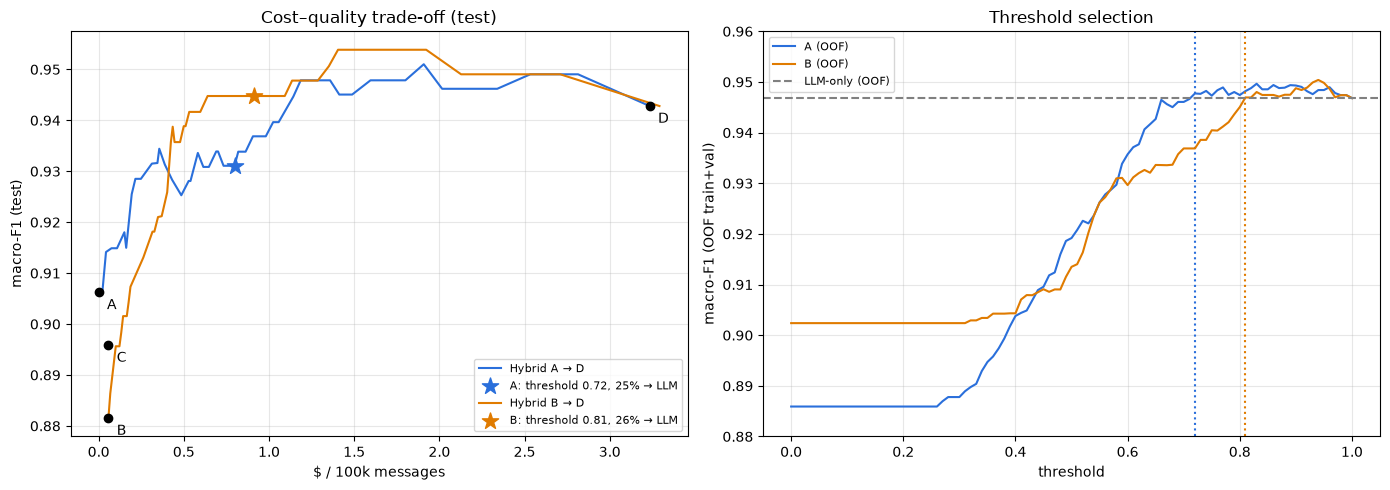

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"A": "#2a6fdb", "B": "#e07b00"}
for k in "AB":
    cv_curve, te_curve = curves[k]
    axes[0].plot(te_curve.cost_per_100k, te_curve.macro_f1, color=colors[k], label=f"Hybrid {k} → D")
    pt = te_curve.set_index("threshold").loc[chosen[k]]
    axes[0].scatter(pt.cost_per_100k, pt.macro_f1, marker="*", s=150, color=colors[k], zorder=5,
                    label=f"{k}: threshold {chosen[k]:.2f}, {pt.routed_pct:.0f}% → LLM")
    axes[1].plot(cv_curve.threshold, cv_curve.macro_f1, color=colors[k], label=f"{k} (OOF)")
    axes[1].axvline(chosen[k], color=colors[k], ls=":")
for k in "ABCD":
    f1 = ex.macro_f1(te.label, preds[k])
    axes[0].scatter(cost[k], f1, color="black", zorder=6); axes[0].annotate(k, (cost[k], f1), xytext=(6, -12), textcoords="offset points")
axes[1].axhline(llm_only_cv, color="gray", ls="--", label="LLM-only (OOF)")
axes[0].set(xlabel="$ / 100k messages", ylabel="macro-F1 (test)", title="Cost–quality trade-off (test)")
axes[1].set(xlabel="threshold", ylabel="macro-F1 (OOF train+val)", title="Threshold selection", ylim=(0.88, 0.96))
for ax in axes: ax.grid(alpha=.3); ax.legend(fontsize=8)
fig.tight_layout()

### Conclusions

- **A → D, threshold 0.72**: ~75% of messages handled locally in under 1 ms, only ~25% call the LLM → **~75% cost reduction** vs. LLM-only, test macro-F1 0.931 (LLM-only 0.943, within the confidence interval). p50 stays < 1 ms.
- **B → D, threshold 0.81**: macro-F1 0.945 — **on par with LLM-only** at ~28% of the cost, but every message pays an extra ~240 ms for the embedding.
- The 0.8 threshold from the brief is close to the one B picks on its own (0.81); for A, 0.72 is already enough to reach LLM level on OOF.

Router for project #3: `intent_router.router.IntentRouter` (A → D, threshold 0.72 stored in `models/tfidf_lr.joblib`; the deployed model is refit on train+val).

In [14]:
for text in ["Gói Pro giá bao nhiêu?", "ko muốn xài nữa", "app cứ văng ra hoài, chán"]:
    p = models["A"].predict_proba([text])[0]
    print(models["A"].classes_[p.argmax()], round(p.max(), 2), text)

pricing 1.0 Gói Pro giá bao nhiêu?
cancellation 0.82 ko muốn xài nữa
complaint 0.84 app cứ văng ra hoài, chán
